# EDA 15.2: Revenue, Traffic, and Promotion Interaction

This notebook analyzes the relationship among Revenue, web traffic, and promotions, including whether promotion periods appear to change the observed relationship between traffic and Revenue.

## 1. Setup and File Discovery

Locate required and optional CSV files under the current working directory. Missing files produce warnings and the notebook continues where possible.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 240)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['sales.csv', 'web_traffic.csv', 'promotions.csv', 'orders.csv', 'order_items.csv']
REQUIRED = {'sales.csv', 'web_traffic.csv', 'promotions.csv'}

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in REQUIRED, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in REQUIRED:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,sales.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...
1,web_traffic.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\we...
2,promotions.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
3,orders.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
4,order_items.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...


## 2. Load Sales, Web Traffic, Promotions, and Optional Files

Load all available inputs safely with pandas and display schema context.

In [2]:
def load_csv_safe(path):
    if path is None:
        return None
    try:
        return pd.read_csv(path, low_memory=False)
    except Exception as exc:
        warnings.warn(f'Failed to load {path}: {exc}')
        return None

data = {name.replace('.csv', ''): load_csv_safe(path) for name, path in selected_paths.items()}
sales = data.get('sales')
web_traffic = data.get('web_traffic')
promotions = data.get('promotions')
orders = data.get('orders')
order_items = data.get('order_items')

schema_rows = []
for name, df in data.items():
    schema_rows.append({
        'dataset': name,
        'loaded': df is not None,
        'rows': None if df is None else len(df),
        'columns': None if df is None else ', '.join(map(str, df.columns[:20]))
    })
display(pd.DataFrame(schema_rows))

,dataset,loaded,rows,columns
0,sales,True,3833,"Date, Revenue, COGS"
1,web_traffic,True,3652,"date, sessions, unique_visitors, page_views, b..."
2,promotions,True,50,"promo_id, promo_name, promo_type, discount_val..."
3,orders,True,646945,"order_id, order_date, customer_id, zip, order_..."
4,order_items,True,714669,"order_id, product_id, quantity, unit_price, di..."


## 3. Identify Revenue, Traffic, Promotion, Source, and Date Columns

Use tolerant matching for likely naming variations. Revenue is inferred from `sales.csv`, traffic from `web_traffic.csv`, and promo dates from `promotions.csv`.

In [3]:
def normalized_map(columns):
    return {normalize_name(c): c for c in columns}

def find_column(columns, candidates, contains=False):
    nmap = normalized_map(columns)
    normalized_candidates = [normalize_name(c) for c in candidates]
    for cand in normalized_candidates:
        if cand in nmap:
            return nmap[cand]
    if contains:
        for cand in normalized_candidates:
            for ncol, raw in nmap.items():
                if cand in ncol:
                    return raw
    return None

sales_cols = {}
if sales is not None:
    sales_cols = {
        'date': find_column(sales.columns, ['date', 'sales_date', 'order_date'], contains=True),
        'revenue': find_column(sales.columns, ['revenue', 'sales_amount', 'total_revenue', 'amount'], contains=True),
    }

traffic_cols = {}
if web_traffic is not None:
    traffic_cols = {
        'date': find_column(web_traffic.columns, ['date', 'traffic_date'], contains=True),
        'sessions': find_column(web_traffic.columns, ['sessions']),
        'page_views': find_column(web_traffic.columns, ['page_views', 'pageviews'], contains=True),
        'unique_visitors': find_column(web_traffic.columns, ['unique_visitors', 'users', 'visitors'], contains=True),
        'bounce_rate': find_column(web_traffic.columns, ['bounce_rate'], contains=True),
        'traffic_source': find_column(web_traffic.columns, ['traffic_source', 'channel', 'source', 'medium'], contains=True),
    }

promo_cols = {}
if promotions is not None:
    promo_cols = {
        'promo_id': find_column(promotions.columns, ['promo_id', 'promotion_id', 'campaign_id'], contains=True),
        'start_date': find_column(promotions.columns, ['start_date', 'promo_start_date', 'begin_date'], contains=True),
        'end_date': find_column(promotions.columns, ['end_date', 'promo_end_date', 'finish_date'], contains=True),
        'promo_type': find_column(promotions.columns, ['promo_type', 'promotion_type', 'type'], contains=True),
        'discount_value': find_column(promotions.columns, ['discount_value', 'discount_amount', 'discount', 'value'], contains=True),
    }

identified = pd.DataFrame({
    'sales': pd.Series(sales_cols),
    'web_traffic': pd.Series(traffic_cols),
    'promotions': pd.Series(promo_cols),
})
display(identified)

if sales is not None and (sales_cols.get('date') is None or sales_cols.get('revenue') is None):
    warnings.warn('Sales date or Revenue column could not be identified reliably.')
if web_traffic is not None and (traffic_cols.get('date') is None or traffic_cols.get('sessions') is None):
    warnings.warn('Traffic date or sessions column could not be identified reliably.')

,sales,web_traffic,promotions
bounce_rate,NaN,bounce_rate,NaN
date,Date,date,NaN
discount_value,NaN,NaN,discount_value
end_date,NaN,NaN,end_date
page_views,NaN,page_views,NaN
promo_id,NaN,NaN,promo_id
promo_type,NaN,NaN,promo_type
revenue,Revenue,NaN,NaN
sessions,NaN,sessions,NaN
start_date,NaN,NaN,start_date


## 4. Prepare Daily Revenue

Standardize sales dates and Revenue, then build a daily Revenue series.

In [4]:
interaction_warnings = []
daily_revenue = pd.DataFrame()

if sales is not None and sales_cols.get('date') and sales_cols.get('revenue'):
    sales_clean = sales.copy()
    sales_clean['date_std'] = pd.to_datetime(sales_clean[sales_cols['date']], errors='coerce')
    sales_clean['revenue_std'] = pd.to_numeric(sales_clean[sales_cols['revenue']], errors='coerce')
    daily_revenue = sales_clean.groupby('date_std').agg(Revenue=('revenue_std', 'sum')).reset_index().rename(columns={'date_std': 'date'})
    rev_quality = pd.DataFrame([{
        'Revenue_date_start': daily_revenue['date'].min(),
        'Revenue_date_end': daily_revenue['date'].max(),
        'missing_dates_after_agg': int(pd.date_range(daily_revenue['date'].min(), daily_revenue['date'].max(), freq='D').difference(daily_revenue['date']).size),
        'duplicate_raw_dates': int(sales_clean.duplicated(subset=['date_std']).sum()),
        'zero_or_negative_revenue_rows': int(sales_clean['revenue_std'].fillna(0).le(0).sum()),
    }])
    display(rev_quality)
    display(sales_clean['revenue_std'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame('revenue_summary'))
    if rev_quality.loc[0, 'zero_or_negative_revenue_rows'] > 0:
        interaction_warnings.append(f"{rev_quality.loc[0, 'zero_or_negative_revenue_rows']} sales rows have zero or negative revenue")
else:
    warnings.warn('Daily Revenue could not be prepared from sales.csv.')

,Revenue_date_start,Revenue_date_end,missing_dates_after_agg,duplicate_raw_dates,zero_or_negative_revenue_rows
0,2012-07-04,2022-12-31,0,0,0


,revenue_summary
count,"3,833.0000"
mean,"4,286,584.0296"
std,"2,624,840.1982"
min,"279,813.9400"
25%,"2,471,088.8200"
50%,"3,647,303.9000"
75%,"5,350,877.2000"
90%,"7,685,788.5300"
95%,"9,398,759.8720"
max,"20,905,271.3500"


## 5. Prepare Daily Web Traffic

Aggregate traffic by day and prepare source-level daily sessions when traffic source is available.

In [5]:
daily_traffic = pd.DataFrame()
source_daily = pd.DataFrame()

if web_traffic is not None and traffic_cols.get('date') and traffic_cols.get('sessions'):
    wt = web_traffic.copy()
    wt['date_std'] = pd.to_datetime(wt[traffic_cols['date']], errors='coerce')
    wt['sessions_std'] = pd.to_numeric(wt[traffic_cols['sessions']], errors='coerce')
    wt['page_views_std'] = pd.to_numeric(wt[traffic_cols['page_views']], errors='coerce') if traffic_cols.get('page_views') else np.nan
    wt['unique_visitors_std'] = pd.to_numeric(wt[traffic_cols['unique_visitors']], errors='coerce') if traffic_cols.get('unique_visitors') else np.nan
    wt['bounce_rate_std'] = pd.to_numeric(wt[traffic_cols['bounce_rate']], errors='coerce') if traffic_cols.get('bounce_rate') else np.nan
    wt['traffic_source_std'] = wt[traffic_cols['traffic_source']].astype(str).str.strip().str.lower() if traffic_cols.get('traffic_source') else pd.NA

    daily_traffic = wt.groupby('date_std').apply(
        lambda d: pd.Series({
            'sessions': d['sessions_std'].sum(),
            'page_views': d['page_views_std'].sum() if 'page_views_std' in d else np.nan,
            'unique_visitors': d['unique_visitors_std'].sum() if 'unique_visitors_std' in d else np.nan,
            'bounce_rate': np.average(d['bounce_rate_std'].fillna(0), weights=d['sessions_std'].clip(lower=0)) if d['bounce_rate_std'].notna().any() and d['sessions_std'].fillna(0).sum() > 0 else np.nan,
        })
    ).reset_index().rename(columns={'date_std': 'date'})

    traffic_quality = pd.DataFrame([{
        'traffic_date_start': daily_traffic['date'].min(),
        'traffic_date_end': daily_traffic['date'].max(),
        'missing_dates_after_agg': int(pd.date_range(daily_traffic['date'].min(), daily_traffic['date'].max(), freq='D').difference(daily_traffic['date']).size),
        'duplicate_raw_dates': int(wt.duplicated(subset=['date_std']).sum()),
        'missing_sessions': int(wt['sessions_std'].isna().sum()),
        'zero_or_negative_sessions': int(wt['sessions_std'].fillna(0).le(0).sum()),
    }])
    display(traffic_quality)
    display(daily_traffic.head(10))

    if traffic_cols.get('traffic_source'):
        source_daily = wt.groupby(['date_std', 'traffic_source_std']).agg(
            sessions=('sessions_std', 'sum'),
            page_views=('page_views_std', 'sum'),
            unique_visitors=('unique_visitors_std', 'sum'),
        ).reset_index().rename(columns={'date_std': 'date'})
        display(source_daily.head(10))

    if traffic_quality.loc[0, 'zero_or_negative_sessions'] > 0:
        interaction_warnings.append(f"{traffic_quality.loc[0, 'zero_or_negative_sessions']} traffic rows have zero or negative sessions")
else:
    warnings.warn('Daily traffic could not be prepared from web_traffic.csv.')

C:\Users\ACER\AppData\Local\Temp\ipykernel_2868\1184377552.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_traffic = wt.groupby('date_std').apply(


,traffic_date_start,traffic_date_end,missing_dates_after_agg,duplicate_raw_dates,missing_sessions,zero_or_negative_sessions
0,2013-01-01,2022-12-31,0,0,0,0


,date,sessions,page_views,unique_visitors,bounce_rate
0,2013-01-01,"9,760.0000","39,093.0000","7,253.0000",0.0051
1,2013-01-02,"10,456.0000","47,611.0000","8,151.0000",0.0041
2,2013-01-03,"10,076.0000","36,963.0000","7,458.0000",0.0040
3,2013-01-04,"9,973.0000","53,078.0000","8,063.0000",0.0056
4,2013-01-05,"10,223.0000","36,790.0000","7,882.0000",0.0053
5,2013-01-06,"9,545.0000","47,160.0000","6,992.0000",0.0044
6,2013-01-07,"10,203.0000","32,749.0000","7,354.0000",0.0044
7,2013-01-08,"9,456.0000","31,482.0000","7,459.0000",0.0044
8,2013-01-09,"9,162.0000","46,717.0000","7,108.0000",0.0041
9,2013-01-10,"9,887.0000","38,472.0000","7,878.0000",0.0054


,date,traffic_source_std,sessions,page_views,unique_visitors
0,2013-01-01,organic_search,9760,39093,7253
1,2013-01-02,organic_search,10456,47611,8151
2,2013-01-03,direct,10076,36963,7458
3,2013-01-04,direct,9973,53078,8063
4,2013-01-05,referral,10223,36790,7882
5,2013-01-06,social_media,9545,47160,6992
6,2013-01-07,organic_search,10203,32749,7354
7,2013-01-08,paid_search,9456,31482,7459
8,2013-01-09,organic_search,9162,46717,7108
9,2013-01-10,organic_search,9887,38472,7878


## 6. Build Active Promotion Calendar

Expand promotion ranges into a daily calendar and summarize promo intensity by date. Outside the known promo coverage window, promo fields remain unknown rather than forced to zero.

In [6]:
promo_calendar = pd.DataFrame()
promo_cov = {}

if promotions is not None and promo_cols.get('start_date') and promo_cols.get('end_date'):
    pr = promotions.copy()
    pr['promo_id_std'] = pr[promo_cols['promo_id']] if promo_cols.get('promo_id') else np.arange(len(pr))
    pr['start_date_std'] = pd.to_datetime(pr[promo_cols['start_date']], errors='coerce')
    pr['end_date_std'] = pd.to_datetime(pr[promo_cols['end_date']], errors='coerce')
    pr['promo_type_std'] = pr[promo_cols['promo_type']].astype(str).str.strip().str.lower() if promo_cols.get('promo_type') else pd.NA
    pr['discount_value_std'] = pd.to_numeric(pr[promo_cols['discount_value']], errors='coerce') if promo_cols.get('discount_value') else np.nan
    invalid_ranges = pr['start_date_std'].notna() & pr['end_date_std'].notna() & (pr['end_date_std'] < pr['start_date_std'])
    pr_valid = pr[~invalid_ranges & pr['start_date_std'].notna() & pr['end_date_std'].notna()].copy()

    expanded = []
    for row in pr_valid.itertuples():
        for dt in pd.date_range(row.start_date_std, row.end_date_std, freq='D'):
            expanded.append({
                'date': dt,
                'promo_id': row.promo_id_std,
                'promo_type': row.promo_type_std,
                'discount_value': row.discount_value_std,
            })
    promo_days = pd.DataFrame(expanded)

    if not promo_days.empty:
        promo_calendar = promo_days.groupby('date').agg(
            has_promo=('promo_id', lambda s: 1),
            active_promo_count=('promo_id', 'nunique'),
            percentage_promo_count=('promo_type', lambda s: s.str.contains('percent').sum()),
            fixed_promo_count=('promo_type', lambda s: s.str.contains('fixed').sum()),
            avg_discount_value=('discount_value', 'mean'),
            max_discount_value=('discount_value', 'max'),
        ).reset_index()
        promo_cov = {
            'start': promo_calendar['date'].min(),
            'end': promo_calendar['date'].max(),
        }
        coverage = pd.DataFrame([{
            'promo_calendar_start': promo_cov['start'],
            'promo_calendar_end': promo_cov['end'],
            'promo_active_days': len(promo_calendar),
            'max_simultaneous_active_promos': promo_calendar['active_promo_count'].max(),
            'invalid_promotion_date_ranges': int(invalid_ranges.sum()),
        }])
        display(coverage)
        display(promo_calendar.head(10))
    else:
        warnings.warn('Promotion date fields were found but no valid promo calendar could be built.')
        interaction_warnings.append('Promotion calendar could not be built from valid start/end dates')
else:
    warnings.warn('Promotion start and end dates could not be identified. Promo interaction analysis will be limited.')
    interaction_warnings.append('Promotion calendar unavailable')

,promo_calendar_start,promo_calendar_end,promo_active_days,max_simultaneous_active_promos,invalid_promotion_date_ranges
0,2013-01-31,2022-12-31,1707,2,0


,date,has_promo,active_promo_count,percentage_promo_count,fixed_promo_count,avg_discount_value,max_discount_value
0,2013-01-31,1,1,1,0,15.0000,15.0000
1,2013-02-01,1,1,1,0,15.0000,15.0000
2,2013-02-02,1,1,1,0,15.0000,15.0000
3,2013-02-03,1,1,1,0,15.0000,15.0000
4,2013-02-04,1,1,1,0,15.0000,15.0000
5,2013-02-05,1,1,1,0,15.0000,15.0000
6,2013-02-06,1,1,1,0,15.0000,15.0000
7,2013-02-07,1,1,1,0,15.0000,15.0000
8,2013-02-08,1,1,1,0,15.0000,15.0000
9,2013-02-09,1,1,1,0,15.0000,15.0000


## 7. Join Revenue, Traffic, and Promotion Calendar

Join daily Revenue, daily traffic, and the promo calendar. Promo zero-fill is used only inside the known promo coverage window.

In [7]:
analysis_df = pd.DataFrame()

if not daily_revenue.empty and not daily_traffic.empty:
    analysis_df = pd.merge(daily_revenue, daily_traffic, on='date', how='outer', indicator='rev_traffic_merge')
    if not promo_calendar.empty:
        analysis_df = analysis_df.merge(promo_calendar, on='date', how='left', indicator='promo_merge')
        analysis_df['has_promo_known_calendar'] = analysis_df['date'].between(promo_cov['start'], promo_cov['end'])
        promo_fill_cols = ['has_promo', 'active_promo_count', 'percentage_promo_count', 'fixed_promo_count', 'avg_discount_value', 'max_discount_value']
        for col in promo_fill_cols:
            if col in analysis_df.columns:
                analysis_df[col] = np.where(analysis_df['has_promo_known_calendar'], analysis_df[col].fillna(0), analysis_df[col])
        analysis_df['has_promo'] = analysis_df['has_promo'].fillna(np.nan)
    else:
        analysis_df['has_promo_known_calendar'] = False
        analysis_df['has_promo'] = np.nan
        analysis_df['active_promo_count'] = np.nan
        analysis_df['avg_discount_value'] = np.nan

    overlap = pd.DataFrame([{
        'Revenue_only_dates': int((analysis_df['rev_traffic_merge'] == 'left_only').sum()),
        'traffic_only_dates': int((analysis_df['rev_traffic_merge'] == 'right_only').sum()),
        'promo_calendar_only_dates': int((analysis_df.get('promo_merge', pd.Series('', index=analysis_df.index)) == 'right_only').sum()) if 'promo_merge' in analysis_df.columns else 0,
        'overlapping_Revenue_traffic_dates': int((analysis_df['rev_traffic_merge'] == 'both').sum()),
        'overlapping_all_three_dates': int(((analysis_df['rev_traffic_merge'] == 'both') & analysis_df['has_promo_known_calendar'].fillna(False)).sum()) if 'has_promo_known_calendar' in analysis_df.columns else 0,
    }])
    display(overlap)
    display(analysis_df.head(15))

    analysis_df = analysis_df.sort_values('date').reset_index(drop=True)
else:
    warnings.warn('Revenue and traffic overlap could not be built.')

,Revenue_only_dates,traffic_only_dates,promo_calendar_only_dates,overlapping_Revenue_traffic_dates,overlapping_all_three_dates
0,181,0,0,3652,3622


,date,Revenue,sessions,page_views,unique_visitors,bounce_rate,rev_traffic_merge,has_promo,active_promo_count,percentage_promo_count,fixed_promo_count,avg_discount_value,max_discount_value,promo_merge,has_promo_known_calendar
0,2012-07-04,"5,123,547.9400",NaN,NaN,NaN,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,left_only,False
1,2012-07-05,"2,751,773.4500",NaN,NaN,NaN,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,left_only,False
2,2012-07-06,"3,054,029.4200",NaN,NaN,NaN,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,left_only,False
3,2012-07-07,"2,667,930.9400",NaN,NaN,NaN,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,left_only,False
4,2012-07-08,"2,360,851.9000",NaN,NaN,NaN,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,left_only,False
5,2012-07-09,"3,548,386.4600",NaN,NaN,NaN,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,left_only,False
6,2012-07-10,"5,234,938.6200",NaN,NaN,NaN,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,left_only,False
7,2012-07-11,"5,582,884.7800",NaN,NaN,NaN,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,left_only,False
8,2012-07-12,"5,734,632.0200",NaN,NaN,NaN,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,left_only,False
9,2012-07-13,"5,309,511.7100",NaN,NaN,NaN,NaN,left_only,NaN,NaN,NaN,NaN,NaN,NaN,left_only,False


## 8. Revenue vs Traffic Relationship

Measure descriptive association between Revenue and traffic metrics, including lagged sessions.

,metric,correlation
0,Revenue_vs_sessions,0.3211
1,Revenue_vs_sessions_lag_1,0.3216
2,Revenue_vs_sessions_lag_7,0.3092
3,Revenue_vs_page_views,0.3016
4,Revenue_vs_unique_visitors,0.3188


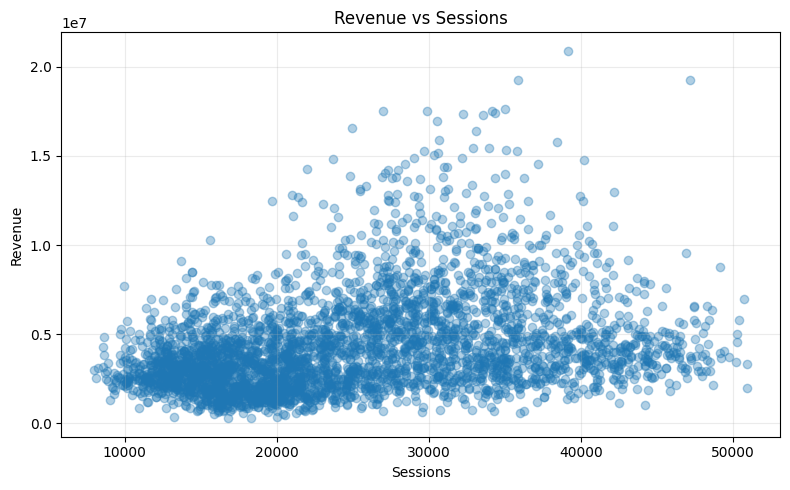

In [8]:
traffic_corr = pd.DataFrame()

if not analysis_df.empty:
    analysis_df['sessions_lag_1'] = analysis_df['sessions'].shift(1)
    analysis_df['sessions_lag_7'] = analysis_df['sessions'].shift(7)
    corr_rows = [
        {'metric': 'Revenue_vs_sessions', 'correlation': analysis_df['Revenue'].corr(analysis_df['sessions'])},
        {'metric': 'Revenue_vs_sessions_lag_1', 'correlation': analysis_df['Revenue'].corr(analysis_df['sessions_lag_1'])},
        {'metric': 'Revenue_vs_sessions_lag_7', 'correlation': analysis_df['Revenue'].corr(analysis_df['sessions_lag_7'])},
    ]
    if 'page_views' in analysis_df.columns:
        corr_rows.append({'metric': 'Revenue_vs_page_views', 'correlation': analysis_df['Revenue'].corr(analysis_df['page_views'])})
    if 'unique_visitors' in analysis_df.columns:
        corr_rows.append({'metric': 'Revenue_vs_unique_visitors', 'correlation': analysis_df['Revenue'].corr(analysis_df['unique_visitors'])})
    traffic_corr = pd.DataFrame(corr_rows)
    display(traffic_corr)

    fig, ax = plt.subplots(figsize=(8, 5))
    tmp = analysis_df.dropna(subset=['Revenue', 'sessions'])
    ax.scatter(tmp['sessions'], tmp['Revenue'], alpha=0.35, color='tab:blue')
    ax.set_title('Revenue vs Sessions')
    ax.set_xlabel('Sessions')
    ax.set_ylabel('Revenue')
    plt.tight_layout()
    plt.show()

## 9. Revenue vs Sessions Colored by Promo Flag

Compare promo and non-promo days only within known promo-calendar coverage.

,has_promo,days,avg_sessions,avg_Revenue,median_Revenue,Revenue_per_session
0,0.0000,1915,"25,673.0522","4,589,436.8997","3,861,128.7600",178.7648
1,1.0000,1707,"24,606.0639","3,990,789.2074","3,428,606.6400",162.1872


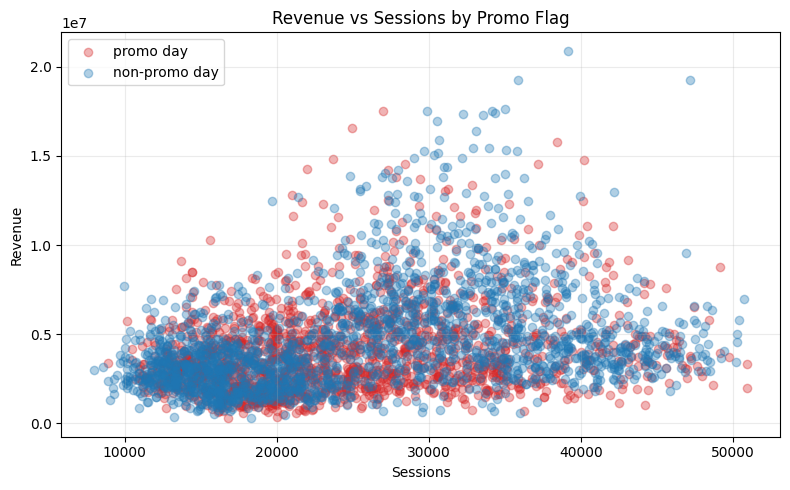

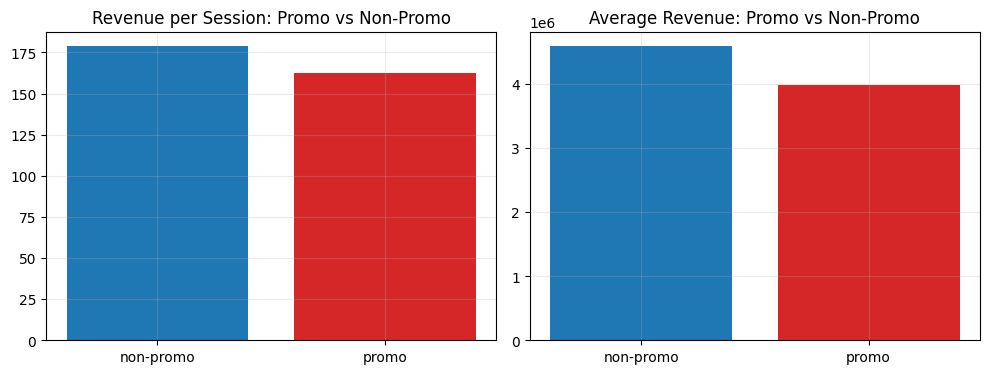

In [9]:
promo_compare = pd.DataFrame()

if not analysis_df.empty and analysis_df['has_promo_known_calendar'].any():
    known = analysis_df[analysis_df['has_promo_known_calendar']].copy()
    promo_compare = known.groupby('has_promo').agg(
        days=('date', 'size'),
        avg_sessions=('sessions', 'mean'),
        avg_Revenue=('Revenue', 'mean'),
        median_Revenue=('Revenue', 'median'),
        Revenue_per_session=('Revenue', lambda s: s.sum() / known.loc[s.index, 'sessions'].sum() if known.loc[s.index, 'sessions'].sum() > 0 else np.nan),
    ).reset_index()
    display(promo_compare)

    fig, ax = plt.subplots(figsize=(8, 5))
    for flag, color, label in [(1, 'tab:red', 'promo day'), (0, 'tab:blue', 'non-promo day')]:
        tmp = known[known['has_promo'] == flag]
        ax.scatter(tmp['sessions'], tmp['Revenue'], alpha=0.35, color=color, label=label)
    ax.set_title('Revenue vs Sessions by Promo Flag')
    ax.set_xlabel('Sessions')
    ax.set_ylabel('Revenue')
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plot_df = promo_compare.sort_values('has_promo')
    axes[0].bar(['non-promo', 'promo'], plot_df['Revenue_per_session'], color=['tab:blue', 'tab:red'])
    axes[0].set_title('Revenue per Session: Promo vs Non-Promo')
    axes[1].bar(['non-promo', 'promo'], plot_df['avg_Revenue'], color=['tab:blue', 'tab:red'])
    axes[1].set_title('Average Revenue: Promo vs Non-Promo')
    plt.tight_layout()
    plt.show()

## 10. Promo/Non-Promo Traffic Conversion Proxy

Compare Revenue per session and related proxies between promo and non-promo days. These are order-value-per-traffic proxies, not true conversion rates.

In [10]:
proxy_compare = pd.DataFrame()

if not analysis_df.empty and analysis_df['has_promo_known_calendar'].any():
    known = analysis_df[analysis_df['has_promo_known_calendar']].copy()
    known['Revenue_per_session'] = np.where(known['sessions'] > 0, known['Revenue'] / known['sessions'], np.nan)
    known['Revenue_per_unique_visitor'] = np.where(known['unique_visitors'] > 0, known['Revenue'] / known['unique_visitors'], np.nan) if 'unique_visitors' in known.columns else np.nan
    known['Revenue_per_page_view'] = np.where(known['page_views'] > 0, known['Revenue'] / known['page_views'], np.nan) if 'page_views' in known.columns else np.nan
    known['promo_intensity_group'] = np.where(known['active_promo_count'].fillna(0) >= known['active_promo_count'].fillna(0).quantile(0.75), 'high_promo_intensity', np.where(known['has_promo'] == 1, 'promo', 'non_promo'))

    proxy_compare = known.groupby('promo_intensity_group').agg(
        days=('date', 'size'),
        avg_Revenue_per_session=('Revenue_per_session', 'mean'),
        avg_Revenue_per_unique_visitor=('Revenue_per_unique_visitor', 'mean'),
        avg_Revenue_per_page_view=('Revenue_per_page_view', 'mean'),
    ).reset_index()
    display(proxy_compare)

,promo_intensity_group,days,avg_Revenue_per_session,avg_Revenue_per_unique_visitor,avg_Revenue_per_page_view
0,high_promo_intensity,1707,172.9658,227.9319,40.8898
1,non_promo,1915,189.4192,249.7251,44.6011


## 11. Promotion Amplification / Interaction Analysis

Compare promo and non-promo traffic-Revenue slopes and evaluate simple interaction features.

,group,days,Revenue_vs_sessions_corr,Revenue_per_session_mean,linear_slope_Revenue_on_sessions
0,non_promo,1915,0.3641,178.7648,103.5003
1,promo,1707,0.2344,162.1872,66.5014


,feature,correlation_with_Revenue
2,sessions_lag_7_x_has_promo,-0.0493
1,sessions_lag_1_x_has_promo,-0.0410
0,sessions_x_has_promo,-0.0397


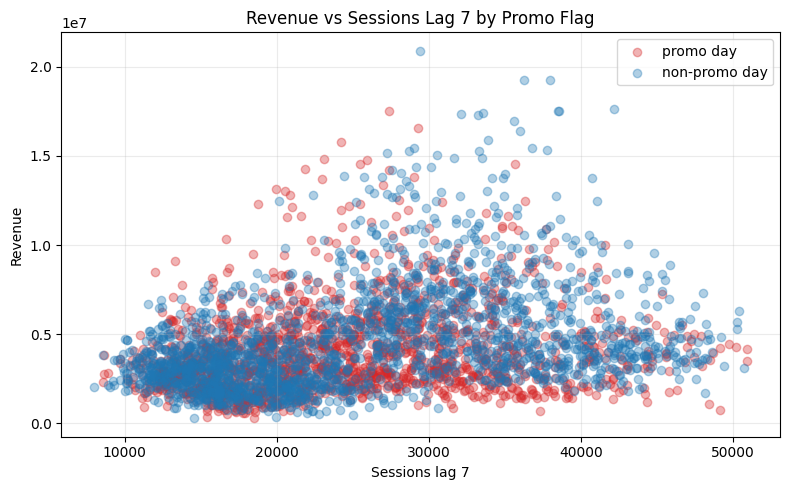

In [11]:
interaction_summary = pd.DataFrame()

if not analysis_df.empty and analysis_df['has_promo_known_calendar'].any():
    known = analysis_df[analysis_df['has_promo_known_calendar']].copy()
    known['sessions_x_has_promo'] = known['sessions'] * known['has_promo']
    known['sessions_lag_1_x_has_promo'] = known['sessions_lag_1'] * known['has_promo']
    known['sessions_lag_7_x_has_promo'] = known['sessions_lag_7'] * known['has_promo']
    rows = []
    for flag, label in [(0, 'non_promo'), (1, 'promo')]:
        grp = known[known['has_promo'] == flag].dropna(subset=['sessions', 'Revenue'])
        if len(grp) >= 2 and grp['sessions'].nunique() > 1:
            slope, intercept = np.polyfit(grp['sessions'], grp['Revenue'], 1)
        else:
            slope, intercept = np.nan, np.nan
        rows.append({
            'group': label,
            'days': len(grp),
            'Revenue_vs_sessions_corr': grp['Revenue'].corr(grp['sessions']),
            'Revenue_per_session_mean': grp['Revenue'].sum() / grp['sessions'].sum() if grp['sessions'].sum() > 0 else np.nan,
            'linear_slope_Revenue_on_sessions': slope,
        })
    interaction_summary = pd.DataFrame(rows)
    display(interaction_summary)

    interaction_feature_corr = pd.DataFrame([
        {'feature': 'sessions_x_has_promo', 'correlation_with_Revenue': known['sessions_x_has_promo'].corr(known['Revenue'])},
        {'feature': 'sessions_lag_1_x_has_promo', 'correlation_with_Revenue': known['sessions_lag_1_x_has_promo'].corr(known['Revenue'])},
        {'feature': 'sessions_lag_7_x_has_promo', 'correlation_with_Revenue': known['sessions_lag_7_x_has_promo'].corr(known['Revenue'])},
    ]).sort_values('correlation_with_Revenue', ascending=False, key=lambda s: s.abs())
    display(interaction_feature_corr)

    fig, ax = plt.subplots(figsize=(8, 5))
    tmp = known.dropna(subset=['Revenue', 'sessions_lag_7'])
    for flag, color, label in [(1, 'tab:red', 'promo day'), (0, 'tab:blue', 'non-promo day')]:
        sub = tmp[tmp['has_promo'] == flag]
        ax.scatter(sub['sessions_lag_7'], sub['Revenue'], alpha=0.35, color=color, label=label)
    ax.set_title('Revenue vs Sessions Lag 7 by Promo Flag')
    ax.set_xlabel('Sessions lag 7')
    ax.set_ylabel('Revenue')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    interaction_feature_corr = pd.DataFrame()

## 12. Traffic Channel Effectiveness on Promo Days

If traffic source exists, compare source behavior on promo and non-promo days.

,traffic_source_std,has_promo,total_sessions,avg_daily_sessions,avg_Revenue,Revenue_per_source_session,Revenue_corr
0,direct,0.0000,3710522,"25,241.6463","4,472,762.3235",177.1977,0.3454
1,direct,1.0000,2823175,"24,549.3478","3,948,085.8264",160.8224,0.3347
2,email_campaign,0.0000,6944133,"25,529.9007","4,626,545.6353",181.2207,0.4031
3,email_campaign,1.0000,5798888,"25,433.7193","3,926,643.2497",154.3873,0.1739
4,organic_search,0.0000,14244803,"25,712.6408","4,398,643.8383",171.0693,0.3599
5,organic_search,1.0000,12874035,"24,382.6420","3,992,215.7323",163.7319,0.2229
6,paid_search,0.0000,10407180,"25,696.7407","4,689,543.5119",182.4957,0.3672
7,paid_search,1.0000,9127549,"24,536.4220","3,990,829.0325",162.6492,0.2310
8,referral,0.0000,5157781,"26,181.6294","4,640,495.2872",177.2424,0.3548
9,referral,1.0000,4290930,"24,519.6000","3,909,571.1818",159.4468,0.2481


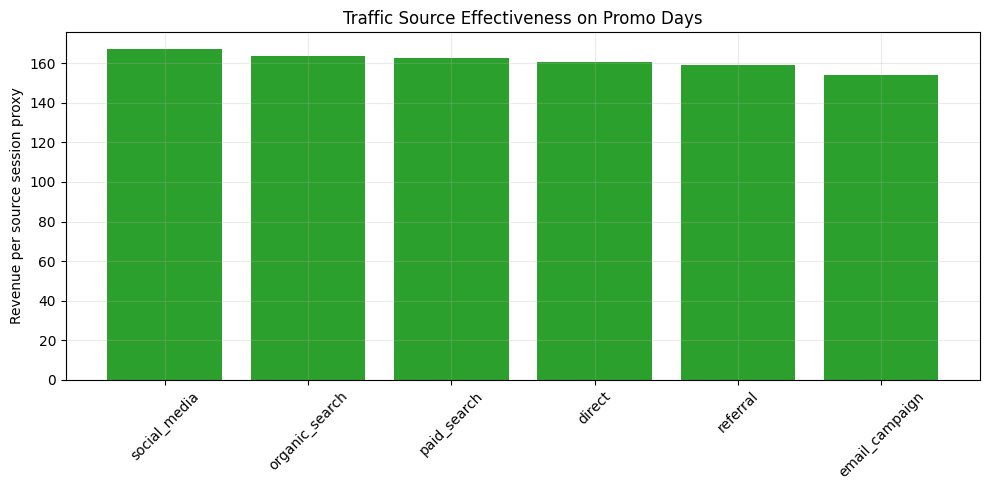

In [12]:
source_effectiveness = pd.DataFrame()

if not source_daily.empty and not analysis_df.empty and analysis_df['has_promo_known_calendar'].any():
    source_join = source_daily.merge(analysis_df[['date', 'Revenue', 'has_promo', 'has_promo_known_calendar']], on='date', how='left')
    source_join = source_join[source_join['has_promo_known_calendar'] == True].copy()
    source_effectiveness = source_join.groupby(['traffic_source_std', 'has_promo']).agg(
        total_sessions=('sessions', 'sum'),
        avg_daily_sessions=('sessions', 'mean'),
        avg_Revenue=('Revenue', 'mean'),
        Revenue_per_source_session=('Revenue', lambda s: s.sum() / source_join.loc[s.index, 'sessions'].sum() if source_join.loc[s.index, 'sessions'].sum() > 0 else np.nan),
        Revenue_corr=('Revenue', lambda s: s.corr(source_join.loc[s.index, 'sessions'])),
    ).reset_index()
    display(source_effectiveness)

    promo_source = source_effectiveness[source_effectiveness['has_promo'] == 1].sort_values('Revenue_per_source_session', ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(promo_source['traffic_source_std'].astype(str), promo_source['Revenue_per_source_session'], color='tab:green')
    ax.set_title('Traffic Source Effectiveness on Promo Days')
    ax.set_ylabel('Revenue per source session proxy')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Traffic-source-specific promo analysis is unavailable because traffic source could not be linked.')

## 13. Revenue Spike Context: Traffic + Promo

Classify Revenue spike days by whether they coincide with high traffic, active promotions, both, or neither.

In [13]:
spike_context = pd.DataFrame()

if not analysis_df.empty:
    rev_thr = analysis_df['Revenue'].quantile(0.95)
    sess_thr = analysis_df['sessions'].quantile(0.90)
    spike_context = analysis_df[analysis_df['Revenue'] >= rev_thr].copy()
    spike_context['sessions_percentile'] = spike_context['sessions'].rank(pct=True)
    spike_context['Revenue_per_session'] = np.where(spike_context['sessions'] > 0, spike_context['Revenue'] / spike_context['sessions'], np.nan)

    def classify(row):
        high_traffic = row['sessions'] >= sess_thr
        has_promo = (row['has_promo'] == 1) if pd.notna(row['has_promo']) else False
        if high_traffic and has_promo:
            return 'high_traffic_plus_promo'
        if high_traffic:
            return 'high_traffic_only'
        if has_promo:
            return 'promo_only'
        return 'unclear'

    spike_context['spike_context'] = spike_context.apply(classify, axis=1)
    display(spike_context[['date', 'Revenue', 'sessions', 'sessions_percentile', 'has_promo', 'active_promo_count', 'Revenue_per_session', 'spike_context']].sort_values('Revenue', ascending=False).head(20))

,date,Revenue,sessions,sessions_percentile,has_promo,active_promo_count,Revenue_per_session,spike_context
2156,2018-05-30,"20,905,271.3500","39,158.0000",0.9206,0.0000,0.0000,533.8697,high_traffic_only
2157,2018-05-31,"19,289,944.1200","35,888.0000",0.8307,0.0000,0.0000,537.5040,unclear
2158,2018-06-01,"19,245,165.7800","47,179.0000",1.0000,0.0000,0.0000,407.9181,high_traffic_only
1793,2017-06-01,"17,639,270.8800","35,023.0000",0.7831,0.0000,0.0000,503.6482,unclear
2159,2018-06-02,"17,529,108.3400","29,884.0000",0.4339,0.0000,0.0000,586.5717,unclear
1794,2017-06-02,"17,528,852.8800","34,130.0000",0.7407,0.0000,0.0000,513.5908,unclear
1730,2017-03-30,"17,516,038.8200","26,971.0000",0.2116,1.0000,1.0000,649.4397,promo_only
1394,2016-04-28,"17,388,183.1900","34,354.0000",0.7513,0.0000,0.0000,506.1473,unclear
664,2014-04-29,"17,347,427.2700","32,248.0000",0.6138,0.0000,0.0000,537.9381,unclear
1792,2017-05-31,"17,314,841.8600","33,594.0000",0.7090,0.0000,0.0000,515.4147,unclear


## 14. Correlation Heatmap-Style Matrix

Display a descriptive numeric correlation matrix and a matplotlib heatmap-style view.

,Revenue,sessions,sessions_lag_1,sessions_lag_7,page_views,unique_visitors,has_promo,active_promo_count,avg_discount_value,Revenue_per_session,sessions_x_has_promo
Revenue,1.0000,0.3211,0.3216,0.3092,0.3016,0.3188,-0.1120,-0.1054,-0.1540,0.7525,-0.0360
sessions,0.3211,1.0000,0.9378,0.8998,0.9196,0.9920,-0.0569,-0.0534,-0.0053,-0.2831,0.2211
sessions_lag_1,0.3216,0.9378,1.0000,0.9070,0.8597,0.9288,-0.0555,-0.0496,-0.0046,-0.2431,0.2015
sessions_lag_7,0.3092,0.8998,0.9070,1.0000,0.8271,0.8923,-0.0503,-0.0422,-0.0075,-0.2369,0.1900
page_views,0.3016,0.9196,0.8597,0.8271,1.0000,0.9114,-0.0522,-0.0500,-0.0061,-0.2554,0.2034
unique_visitors,0.3188,0.9920,0.9288,0.8923,0.9114,1.0000,-0.0591,-0.0556,-0.0086,-0.2792,0.2149
has_promo,-0.1120,-0.0569,-0.0555,-0.0503,-0.0522,-0.0591,1.0000,0.9895,0.7872,-0.0788,0.9045
active_promo_count,-0.1054,-0.0534,-0.0496,-0.0422,-0.0500,-0.0556,0.9895,1.0000,0.7891,-0.0738,0.8970
avg_discount_value,-0.1540,-0.0053,-0.0046,-0.0075,-0.0061,-0.0086,0.7872,0.7891,1.0000,-0.1432,0.7392
Revenue_per_session,0.7525,-0.2831,-0.2431,-0.2369,-0.2554,-0.2792,-0.0788,-0.0738,-0.1432,1.0000,-0.1661


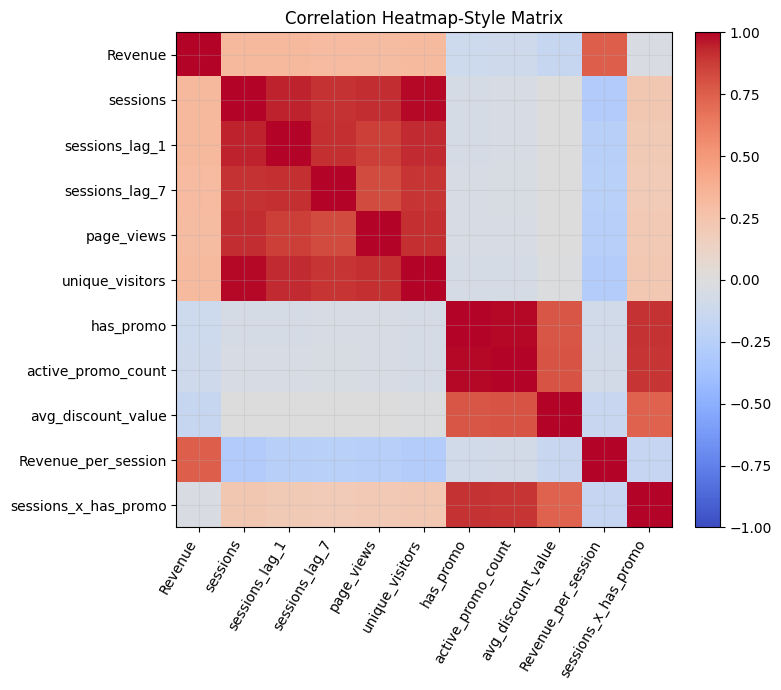

In [14]:
corr_matrix = pd.DataFrame()

if not analysis_df.empty:
    heat = analysis_df.copy()
    heat['Revenue_per_session'] = np.where(heat['sessions'] > 0, heat['Revenue'] / heat['sessions'], np.nan)
    heat['sessions_x_has_promo'] = heat['sessions'] * heat['has_promo'].fillna(0)
    numeric_cols = ['Revenue', 'sessions', 'sessions_lag_1', 'sessions_lag_7']
    for col in ['page_views', 'unique_visitors', 'has_promo', 'active_promo_count', 'avg_discount_value', 'Revenue_per_session', 'sessions_x_has_promo']:
        if col in heat.columns:
            numeric_cols.append(col)
    corr_matrix = heat[numeric_cols].corr()
    display(corr_matrix)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=60, ha='right')
    ax.set_yticks(range(len(corr_matrix.index)))
    ax.set_yticklabels(corr_matrix.index)
    ax.set_title('Correlation Heatmap-Style Matrix')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

## 15. Leakage-Safe Traffic x Promo Feature Preview

Create candidate interaction features using lagged traffic and known-calendar promo signals only.

In [15]:
feature_preview = pd.DataFrame()

if not analysis_df.empty:
    feat = analysis_df.sort_values('date').copy()
    feat['sessions_lag_1'] = feat['sessions'].shift(1)
    feat['sessions_lag_7'] = feat['sessions'].shift(7)
    feat['sessions_roll_mean_7_lagged'] = feat['sessions'].shift(1).rolling(7, min_periods=1).mean()
    if 'page_views' in feat.columns:
        feat['page_views_lag_7'] = feat['page_views'].shift(7)
    feat['has_promo_known_calendar'] = feat['has_promo_known_calendar'].fillna(False)
    feat['has_promo_safe'] = np.where(feat['has_promo_known_calendar'], feat['has_promo'].fillna(0), np.nan)
    feat['sessions_lag_1_x_has_promo'] = feat['sessions_lag_1'] * feat['has_promo_safe']
    feat['sessions_lag_7_x_has_promo'] = feat['sessions_lag_7'] * feat['has_promo_safe']
    feat['sessions_roll_mean_7_x_has_promo'] = feat['sessions_roll_mean_7_lagged'] * feat['has_promo_safe']
    feat['active_promo_count_x_sessions_lag_7'] = feat['active_promo_count'].fillna(0) * feat['sessions_lag_7']

    preview_cols = ['date', 'Revenue', 'sessions']
    for col in ['page_views', 'unique_visitors', 'has_promo', 'active_promo_count', 'avg_discount_value']:
        if col in feat.columns:
            preview_cols.append(col)
    preview_cols += [
        'sessions_lag_1', 'sessions_lag_7', 'sessions_roll_mean_7_lagged',
        'has_promo_known_calendar', 'sessions_lag_1_x_has_promo',
        'sessions_lag_7_x_has_promo', 'sessions_roll_mean_7_x_has_promo',
        'active_promo_count_x_sessions_lag_7'
    ]
    if 'page_views_lag_7' in feat.columns:
        preview_cols.insert(preview_cols.index('has_promo_known_calendar'), 'page_views_lag_7')
    feature_preview = feat[preview_cols].head(20)
    display(feature_preview)

print('Interaction features are valid only when both components are valid at prediction time.')
print('Known promo calendar features can be used for future dates only if the future promo calendar is available in advance.')
print('Future traffic must be known or forecasted before using traffic x promo interaction features for future prediction.')

,date,Revenue,sessions,page_views,unique_visitors,has_promo,active_promo_count,avg_discount_value,sessions_lag_1,sessions_lag_7,sessions_roll_mean_7_lagged,page_views_lag_7,has_promo_known_calendar,sessions_lag_1_x_has_promo,sessions_lag_7_x_has_promo,sessions_roll_mean_7_x_has_promo,active_promo_count_x_sessions_lag_7
0,2012-07-04,"5,123,547.9400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
1,2012-07-05,"2,751,773.4500",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
2,2012-07-06,"3,054,029.4200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
3,2012-07-07,"2,667,930.9400",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
4,2012-07-08,"2,360,851.9000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
5,2012-07-09,"3,548,386.4600",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
6,2012-07-10,"5,234,938.6200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
7,2012-07-11,"5,582,884.7800",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
8,2012-07-12,"5,734,632.0200",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
9,2012-07-13,"5,309,511.7100",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN


Interaction features are valid only when both components are valid at prediction time.
Known promo calendar features can be used for future dates only if the future promo calendar is available in advance.
Future traffic must be known or forecasted before using traffic x promo interaction features for future prediction.


## 16. Key Observations and Warnings

Summarize whether traffic appears associated with Revenue, whether promo days change the observed relationship, and which interaction features look most promising.

In [16]:
summary_lines = ['KEY OBSERVATIONS AND WARNINGS']

if not traffic_corr.empty:
    rev_sess = traffic_corr.loc[traffic_corr['metric'] == 'Revenue_vs_sessions', 'correlation']
    if not rev_sess.empty:
        summary_lines.append(f"- Traffic appears associated with Revenue under same-day sessions correlation {rev_sess.iloc[0]:.4f}.")

if not promo_compare.empty:
    promo_rps = promo_compare.loc[promo_compare['has_promo'] == 1, 'Revenue_per_session']
    nonpromo_rps = promo_compare.loc[promo_compare['has_promo'] == 0, 'Revenue_per_session']
    if not promo_rps.empty and not nonpromo_rps.empty:
        higher = 'higher' if promo_rps.iloc[0] > nonpromo_rps.iloc[0] else 'lower'
        summary_lines.append(f"- Promo days show {higher} Revenue per session than non-promo days: {promo_rps.iloc[0]:,.4f} vs {nonpromo_rps.iloc[0]:,.4f}.")

if not interaction_summary.empty:
    promo_slope = interaction_summary.loc[interaction_summary['group'] == 'promo', 'linear_slope_Revenue_on_sessions']
    non_slope = interaction_summary.loc[interaction_summary['group'] == 'non_promo', 'linear_slope_Revenue_on_sessions']
    if not promo_slope.empty and not non_slope.empty:
        relation = 'stronger' if abs(promo_slope.iloc[0]) > abs(non_slope.iloc[0]) else 'weaker'
        summary_lines.append(f"- Promo days show a {relation} observed traffic-Revenue slope than non-promo days ({promo_slope.iloc[0]:,.4f} vs {non_slope.iloc[0]:,.4f}).")

if not source_effectiveness.empty:
    top_sources = source_effectiveness[source_effectiveness['has_promo'] == 1].sort_values('Revenue_per_source_session', ascending=False).head(3)
    if not top_sources.empty:
        summary_lines.append('- Traffic channels that appear more effective on promo days: ' + ', '.join(f"{r.traffic_source_std}" for r in top_sources.itertuples()) + '.')
else:
    summary_lines.append('- Traffic channel effectiveness on promo days could not be assessed beyond overall traffic because source linkage was unavailable.')

if not spike_context.empty:
    counts = spike_context['spike_context'].value_counts()
    spike_text = ', '.join(f"{idx} ({val})" for idx, val in counts.items())
    summary_lines.append(f'- Revenue spike categories: {spike_text}.')

if not interaction_feature_corr.empty:
    top_features = interaction_feature_corr.head(3)
    summary_lines.append('- Strongest candidate interaction features: ' + ', '.join(f"{r.feature} ({r.correlation_with_Revenue:.4f})" for r in top_features.itertuples()) + '.')

if interaction_warnings:
    summary_lines.append('- Data quality warnings related to sales, traffic, and promotion calendar: ' + '; '.join(interaction_warnings))
else:
    summary_lines.append('- Data quality warnings related to sales, traffic, and promotion calendar: none beyond the checks reported in notebook tables.')

summary_lines.append('- Recommended leakage-safe traffic x promotion features: sessions_lag_1, sessions_lag_7, sessions_roll_mean_7_lagged, has_promo_known_calendar, sessions_lag_1_x_has_promo, sessions_lag_7_x_has_promo, sessions_roll_mean_7_x_has_promo, and active_promo_count_x_sessions_lag_7.')
summary_lines.append('- sessions_x_promo is valid only when both components are valid at prediction time. Future traffic must be known or forecasted, and future promo calendar must be known before using future promo features.')
summary_lines.append('- Causal caution: this is observational EDA. Traffic and promotions can both reflect seasonality, targeting, merchandising, channel mix, and broader demand conditions.')

print('\n'.join(summary_lines))

KEY OBSERVATIONS AND WARNINGS
- Traffic appears associated with Revenue under same-day sessions correlation 0.3211.
- Promo days show lower Revenue per session than non-promo days: 162.1872 vs 178.7648.
- Promo days show a weaker observed traffic-Revenue slope than non-promo days (66.5014 vs 103.5003).
- Traffic channels that appear more effective on promo days: social_media, organic_search, paid_search.
- Revenue spike categories: unclear (120), promo_only (55), high_traffic_only (11), high_traffic_plus_promo (6).
- Strongest candidate interaction features: sessions_lag_7_x_has_promo (-0.0493), sessions_lag_1_x_has_promo (-0.0410), sessions_x_has_promo (-0.0397).
- Data quality warnings related to sales, traffic, and promotion calendar: none beyond the checks reported in notebook tables.
- Recommended leakage-safe traffic x promotion features: sessions_lag_1, sessions_lag_7, sessions_roll_mean_7_lagged, has_promo_known_calendar, sessions_lag_1_x_has_promo, sessions_lag_7_x_has_promo, 